# GES Case Study – Exploratory Data Analysis

**Team:** Team One Consulting

**Dataset:** Customer Interactions, Customer Profiles, Data Sources

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

# ── Color palette & chart style ──────────────────────────────────────────────
GES_DARK  = '#01010b'   # black
GES_BLUE  = '#6950ec'   # purple
GES_GOLD  = '#e00e32'   # berry red
GES_TEAL  = '#a3055c'   # maroon

PALETTE = [
    '#6950ec',  # purple
    '#a3055c',  # maroon
    '#e00e32',  # berry red
    '#9e9e9e',  # gray
    '#8a7cff',  # soft purple
    '#c75a93',  # dusty pink
    '#d9d9d9',  # light gray
    '#b23a6f'   # muted berry
]

plt.rcParams.update({
    'figure.facecolor':  GES_DARK,
    'axes.facecolor':    '#141420',
    'savefig.facecolor': GES_DARK,
    'axes.edgecolor':    '#444',
    'axes.labelcolor':   'white',
    'xtick.color':       '#ccc',
    'ytick.color':       '#ccc',
    'text.color':        'white',
    'grid.color':        '#333',
    'grid.linestyle':    '--',
    'grid.alpha':        0.5,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

## 1. Load Data

Three datasets are provided:
- **Customer Interactions** – one row per transaction
- **Customer Profiles** – one row per customer (1st-party only)
- **Data Sources** – metadata on each data source

In [91]:
customer_interactions = pd.read_csv('Data/Customer_Interactions.csv')
customer_profiles     = pd.read_csv('Data/Customer_Profiles.csv')
data_sources          = pd.read_csv('Data/Data_Sources.csv')

print(f'Interactions : {customer_interactions.shape}')
print(f'Profiles     : {customer_profiles.shape}')
print(f'Data Sources : {data_sources.shape}')

Interactions : (2500, 11)
Profiles     : (363, 13)
Data Sources : (9, 10)


In [92]:
customer_interactions.head()

,Transaction ID,Customer ID,Transaction Date,Business Line,Product/Service,Revenue,Data Source,Email,Age Range,Gender,Region
0,TXN000001,CUST00150,2024-01-01,Consumer Products,Merchandise - Collectibles,54.06,3rd Party - Walmart,NaN,NaN,NaN,East Coast
1,TXN000002,CUST00642,2024-01-01,Consumer Products,Merchandise - Apparel,40.87,3rd Party - Target,NaN,NaN,NaN,West Coast
2,TXN000003,CUST00035,2024-01-01,Streaming,Monthly Subscription,10.72,1st Party - Streaming Platform,cust00035@email.com,45-54,Prefer not to say,Southwest
3,TXN000004,CUST00163,2024-01-02,Theatrical,Mystery Manor,17.24,3rd Party - AMC Theatres,NaN,NaN,NaN,Southwest
4,TXN000005,CUST00185,2024-01-02,Theatrical,Space Odyssey 2,27.81,3rd Party - Cinemark,NaN,NaN,NaN,East Coast


In [93]:
customer_profiles.head()

,Customer ID,Email,Age Range,Gender,Primary Business Line,Business Lines Engaged,Total Transactions,Lifetime Value,First Interaction,Last Interaction,Engagement Score,Data Completeness %,Customer Data Type
0,CUST00156,cust00156@email.com,25-34,Other,Studio Tours,5,17,1845.30,2024-01-16,2024-12-14,100,77,Mixed (1st & 3rd Party)
1,CUST00177,cust00177@email.com,25-34,F,Streaming,5,15,1805.88,2024-02-14,2024-12-27,100,96,Mixed (1st & 3rd Party)
2,CUST00223,cust00223@email.com,35-44,M,Online Store,5,19,1802.78,2024-01-05,2024-12-27,100,80,Mixed (1st & 3rd Party)
3,CUST00111,cust00111@email.com,45-54,Prefer not to say,Studio Tours,4,11,1757.35,2024-02-28,2024-12-29,100,90,Mixed (1st & 3rd Party)
4,CUST00087,cust00087@email.com,18-24,F,Consumer Products,4,16,1728.09,2024-01-29,2024-12-12,100,96,Mixed (1st & 3rd Party)


In [94]:
data_sources

,Source ID,Business Line,Data Source Name,Source Type,Customer ID Available,Email Available,Demographics Available,Data Quality,Integration Status,Notes
0,1,Streaming,1st Party - Streaming Platform,1st Party,Yes,Yes,Yes (80% complete),High,Fully Integrated,Complete customer profiles with viewing history
1,2,Online Store,1st Party - Online Store,1st Party,Yes,Yes,Yes (75% complete),High,Fully Integrated,Complete purchase history and customer prefere...
2,3,Studio Tours,1st Party - Studio Tours,1st Party,Yes,Yes,Yes (70% complete),High,Fully Integrated,Ticket purchases and tour preferences
3,4,Theatrical,3rd Party - AMC Theatres,3rd Party,Limited (cinema loyalty ID only),No,No,Medium,Limited - Aggregated Data Only,Currently receives only title-level sales data...
4,5,Theatrical,3rd Party - Regal Cinemas,3rd Party,Limited (cinema loyalty ID only),No,No,Medium,Limited - Aggregated Data Only,Currently receives only title-level sales data...
5,6,Theatrical,3rd Party - Cinemark,3rd Party,Limited (cinema loyalty ID only),No,No,Medium,Limited - Aggregated Data Only,Currently receives only title-level sales data...
6,7,Consumer Products,3rd Party - Target,3rd Party,No,No,No,Low-Medium,Not Integrated,Currently no direct data access; relies on ret...
7,8,Consumer Products,3rd Party - Walmart,3rd Party,No,No,No,Low-Medium,Not Integrated,Currently no direct data access; relies on ret...
8,9,Consumer Products,3rd Party - Amazon,3rd Party,No,No,No,Low-Medium,Not Integrated,Currently no direct data access; relies on ret...


## 2. Initial Exploration

Checking data types, null counts, and duplicates before merging.

In [96]:
print('=== Customer Interactions ===')
customer_interactions.info()

=== Customer Interactions ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    2500 non-null   object 
 1   Customer ID       2500 non-null   object 
 2   Transaction Date  2500 non-null   object 
 3   Business Line     2500 non-null   object 
 4   Product/Service   2500 non-null   object 
 5   Revenue           2500 non-null   float64
 6   Data Source       2500 non-null   object 
 7   Email             1469 non-null   object 
 8   Age Range         1210 non-null   object 
 9   Gender            1210 non-null   object 
 10  Region            2500 non-null   object 
dtypes: float64(1), object(10)
memory usage: 215.0+ KB


In [97]:
print('=== Customer Profiles ===')
customer_profiles.info()

=== Customer Profiles ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 363 entries, 0 to 362
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             363 non-null    object 
 1   Email                   249 non-null    object 
 2   Age Range               248 non-null    object 
 3   Gender                  248 non-null    object 
 4   Primary Business Line   363 non-null    object 
 5   Business Lines Engaged  363 non-null    int64  
 6   Total Transactions      363 non-null    int64  
 7   Lifetime Value          363 non-null    float64
 8   First Interaction       363 non-null    object 
 9   Last Interaction        363 non-null    object 
 10  Engagement Score        363 non-null    int64  
 11  Data Completeness %     363 non-null    int64  
 12  Customer Data Type      363 non-null    object 
dtypes: float64(1), int64(4), object(8)
memory usage: 37.0+ KB


In [98]:
# Check for duplicate transactions
print(f'Duplicate rows in interactions: {customer_interactions.duplicated().sum()}')
print(f'Unique transaction IDs        : {customer_interactions["Transaction ID"].nunique()}')
print(f'Unique customers in interactions: {customer_interactions["Customer ID"].nunique()}')
print(f'Unique customers in profiles    : {customer_profiles["Customer ID"].nunique()}')

Duplicate rows in interactions: 0
Unique transaction IDs        : 2500
Unique customers in interactions: 363
Unique customers in profiles    : 363


## 3. Merging & Cleaning

We merge all three datasets into a single flat table for analysis.

**Step 1** – Tag each interaction as 1st-party or 3rd-party before merging so the column isn't overwritten.  
**Step 2** – Left-join interactions → profiles (keeps all transactions, fills in profile fields where available).  
**Step 3** – Consolidate duplicate demographic columns (Email, Age Range, Gender appear in both datasets).  
**Step 4** – Left-join → data_sources for source-level metadata.

In [100]:
# Step 1 – Tag source type on interactions
customer_interactions['Source Type'] = customer_interactions['Data Source'].apply(
    lambda x: '1st Party' if '1st Party' in x else '3rd Party'
)
customer_interactions['Transaction Date'] = pd.to_datetime(customer_interactions['Transaction Date'])

# Step 2 – Merge interactions with profiles
df = customer_interactions.merge(
    customer_profiles, on='Customer ID', how='left', suffixes=('_txn', '_prof')
)

# Step 3 – Consolidate duplicate demographic columns
# Profile data is more complete; use transaction-level value where available, fill gaps from profile
df['Email']     = df['Email_txn'].combine_first(df['Email_prof'])
df['Age Range'] = df['Age Range_txn'].combine_first(df['Age Range_prof'])
df['Gender']    = df['Gender_txn'].combine_first(df['Gender_prof'])
df.drop(columns=['Email_txn','Email_prof','Age Range_txn','Age Range_prof',
                  'Gender_txn','Gender_prof'], inplace=True)

# Step 4 – Merge with data source metadata
df = df.merge(data_sources, left_on='Data Source', right_on='Data Source Name',
              how='left', suffixes=('', '_ds'))

print(f'Merged dataframe shape: {df.shape}')
df.head()

Merged dataframe shape: (2500, 31)


,Transaction ID,Customer ID,Transaction Date,Business Line,Product/Service,Revenue,Data Source,Region,Source Type,Primary Business Line,Business Lines Engaged,Total Transactions,Lifetime Value,First Interaction,Last Interaction,Engagement Score,Data Completeness %,Customer Data Type,Email,Age Range,Gender,Source ID,Business Line_ds,Data Source Name,Source Type_ds,Customer ID Available,Email Available,Demographics Available,Data Quality,Integration Status,Notes
0,TXN000001,CUST00150,2024-01-01,Consumer Products,Merchandise - Collectibles,54.06,3rd Party - Walmart,East Coast,3rd Party,Consumer Products,1,2,119.98,2024-01-01,2024-09-12,0,16,3rd Party Only,NaN,NaN,NaN,8,Consumer Products,3rd Party - Walmart,3rd Party,No,No,No,Low-Medium,Not Integrated,Currently no direct data access; relies on ret...
1,TXN000002,CUST00642,2024-01-01,Consumer Products,Merchandise - Apparel,40.87,3rd Party - Target,West Coast,3rd Party,Consumer Products,2,4,96.65,2024-01-01,2024-10-26,32,21,3rd Party Only,NaN,NaN,NaN,7,Consumer Products,3rd Party - Target,3rd Party,No,No,No,Low-Medium,Not Integrated,Currently no direct data access; relies on ret...
2,TXN000003,CUST00035,2024-01-01,Streaming,Monthly Subscription,10.72,1st Party - Streaming Platform,Southwest,1st Party,Streaming,5,12,1322.63,2024-01-01,2024-12-23,100,80,Mixed (1st & 3rd Party),cust00035@email.com,45-54,Prefer not to say,1,Streaming,1st Party - Streaming Platform,1st Party,Yes,Yes,Yes (80% complete),High,Fully Integrated,Complete customer profiles with viewing history
3,TXN000004,CUST00163,2024-01-02,Theatrical,Mystery Manor,17.24,3rd Party - AMC Theatres,Southwest,3rd Party,Theatrical,5,11,1156.12,2024-01-02,2024-11-05,100,77,Mixed (1st & 3rd Party),cust00163@email.com,18-24,F,4,Theatrical,3rd Party - AMC Theatres,3rd Party,Limited (cinema loyalty ID only),No,No,Medium,Limited - Aggregated Data Only,Currently receives only title-level sales data...
4,TXN000005,CUST00185,2024-01-02,Theatrical,Space Odyssey 2,27.81,3rd Party - Cinemark,East Coast,3rd Party,Theatrical,2,5,176.20,2024-01-02,2024-10-28,44,83,Mixed (1st & 3rd Party),cust00185@email.com,35-44,F,6,Theatrical,3rd Party - Cinemark,3rd Party,Limited (cinema loyalty ID only),No,No,Medium,Limited - Aggregated Data Only,Currently receives only title-level sales data...


In [101]:
# Export merged dataframe to CSV
df.to_csv("merged_customer_data.csv", index=False)

print("Exported successfully as merged_customer_data.csv")

Exported successfully as merged_customer_data.csv


In [102]:
df.isna().sum()

Transaction ID              0
Customer ID                 0
Transaction Date            0
Business Line               0
Product/Service             0
Revenue                     0
Data Source                 0
Region                      0
Source Type                 0
Primary Business Line       0
Business Lines Engaged      0
Total Transactions          0
Lifetime Value              0
First Interaction           0
Last Interaction            0
Engagement Score            0
Data Completeness %         0
Customer Data Type          0
Email                     226
Age Range                 229
Gender                    229
Source ID                   0
Business Line_ds            0
Data Source Name            0
Source Type_ds              0
Customer ID Available       0
Email Available             0
Demographics Available      0
Data Quality                0
Integration Status          0
Notes                       0
dtype: int64

In [103]:
# Verify the email consolidation worked
# Records where profile filled in a missing interaction email
filled_by_profile = df[(df['Email'].notna())].shape[0]
still_missing     = df['Email'].isna().sum()

print(f'Transactions with email available : {filled_by_profile}')
print(f'Transactions still missing email  : {still_missing}')
print()
print('Key insight: customer profiles are a more complete and reliable source')
print('of customer identifiers than transaction-level data alone.')

Transactions with email available : 2274
Transactions still missing email  : 226

Key insight: customer profiles are a more complete and reliable source
of customer identifiers than transaction-level data alone.


## 4. Data Quality Analysis

**Question:** What data quality issues are present, and how do they impact the ability to understand customer behavior?

In [105]:
# Missing values across the merged dataset
df.isna().sum()[df.isna().sum() > 0]

Email        226
Age Range    229
Gender       229
dtype: int64

In [106]:
# Where do missing values come from? Break down by source type
print('Missing Email by Source Type:')
print(df[df['Email'].isna()].groupby('Source Type').size())
print()
print('Missing Age Range by Source Type:')
print(df[df['Age Range'].isna()].groupby('Source Type').size())
print()
print('Missing Gender by Source Type:')
print(df[df['Gender'].isna()].groupby('Source Type').size())

Missing Email by Source Type:
Source Type
3rd Party    226
dtype: int64

Missing Age Range by Source Type:
Source Type
1st Party      1
3rd Party    228
dtype: int64

Missing Gender by Source Type:
Source Type
1st Party      1
3rd Party    228
dtype: int64


**Finding:** Missing customer identifiers are concentrated almost entirely in 3rd-party sources.

- **100%** of missing email records come from 3rd-party channels (Walmart, Target, Amazon, cinema chains)
- Demographic gaps (Age Range, Gender) follow the same pattern
- First-party data has near-complete profiles — isolated missing values are due to optional fields at sign-up

This confirms a core structural problem: GES can see *what* customers buy through 3rd-party channels, but cannot identify *who* they are. Without email or a customer ID, these interactions cannot be linked back to a known individual.

In [108]:
# Quantify the "dark revenue" problem — revenue GES cannot attribute to a known customer
total_rev   = df['Revenue'].sum()
dark_rev    = df[(df['Source Type'] == '3rd Party') & (df['Email'].isna())]['Revenue'].sum()
pct_dark    = dark_rev / total_rev

print(f'Total revenue           : ${total_rev:,.2f}')
print(f'Unattributable revenue  : ${dark_rev:,.2f} ({pct_dark:.1%} of total)')
print()
print('This is revenue GES cannot connect to a customer profile or cross-channel journey.')

Total revenue           : $210,135.91
Unattributable revenue  : $8,028.53 (3.8% of total)

This is revenue GES cannot connect to a customer profile or cross-channel journey.


### Fig 1 – Data Quality: The Identity Gap

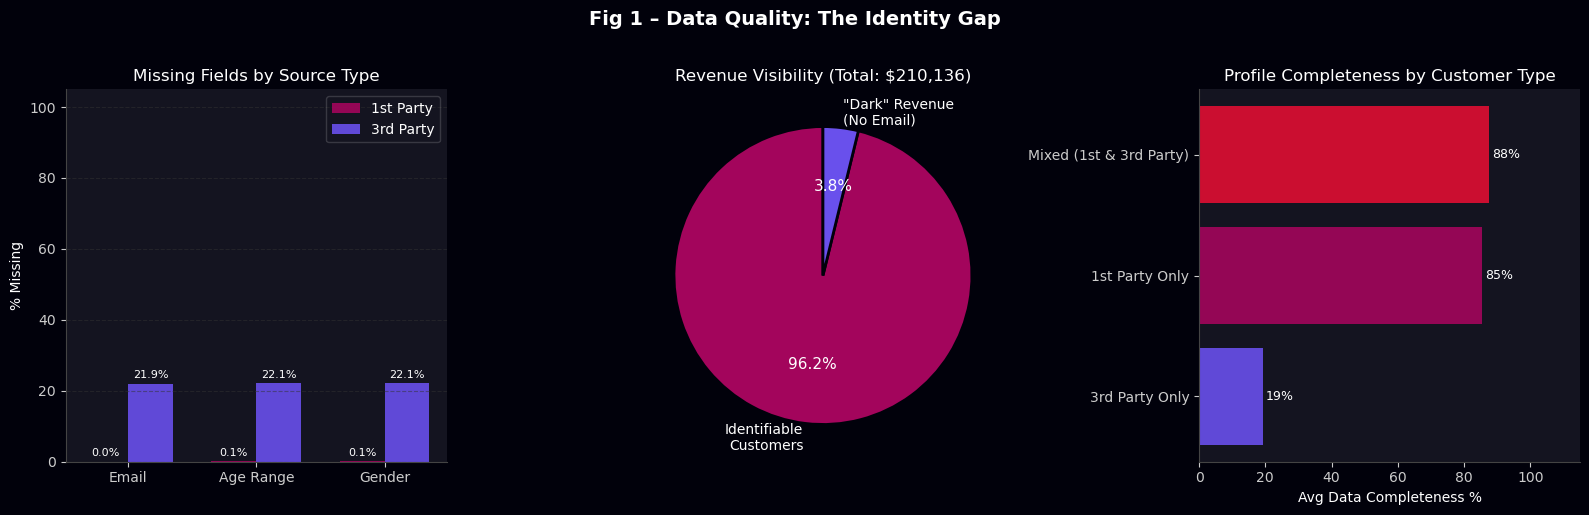

<Figure size 640x480 with 0 Axes>

In [190]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Fig 1 – Data Quality: The Identity Gap', fontsize=14, fontweight='bold', y=1.02)

# 1a – Missing fields by source type
fields      = ['Email', 'Age Range', 'Gender']
missing_1st = [df[df['Source Type']=='1st Party'][f].isna().mean()*100 for f in fields]
missing_3rd = [df[df['Source Type']=='3rd Party'][f].isna().mean()*100 for f in fields]
x, w = np.arange(len(fields)), 0.35
ax   = axes[0]
b1   = ax.bar(x - w/2, missing_1st, w, label='1st Party', color=PALETTE[1], alpha=0.9)
b2   = ax.bar(x + w/2, missing_3rd, w, label='3rd Party', color=PALETTE[0], alpha=0.9)
ax.set_xticks(x); ax.set_xticklabels(fields)
ax.set_ylabel('% Missing'); ax.set_ylim(0, 105)
ax.set_title('Missing Fields by Source Type')
ax.legend(framealpha=0.2); ax.grid(axis='y')
for bar in list(b1)+list(b2):
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+1, f'{h:.1f}%',
            ha='center', va='bottom', fontsize=8)

# 1b – Revenue visibility pie
ident_rev = total_rev - dark_rev
ax = axes[1]
wedges, texts, autotexts = ax.pie(
    [ident_rev, dark_rev],
    labels=['Identifiable\nCustomers', '"Dark" Revenue\n(No Email)'],
    autopct='%1.1f%%', colors=[PALETTE[1], PALETTE[0]],
    startangle=90, wedgeprops=dict(edgecolor=GES_DARK, linewidth=2)
)
for at in autotexts: at.set_color('white'); at.set_fontsize(11)
ax.set_title(f'Revenue Visibility (Total: ${total_rev:,.0f})')

# 1c – Avg data completeness by customer type
ax    = axes[2]
comp  = customer_profiles.groupby('Customer Data Type')['Data Completeness %'].mean().sort_values()
cmap2 = {'1st Party Only': PALETTE[1], '3rd Party Only': PALETTE[0],
          'Mixed (1st & 3rd Party)': PALETTE[2]}
bars  = ax.barh(comp.index, comp.values,
                color=[cmap2.get(i, PALETTE[3]) for i in comp.index], alpha=0.9)
ax.set_xlabel('Avg Data Completeness %')
ax.set_title('Profile Completeness by Customer Type')
ax.set_xlim(0, 115)
for bar in bars:
    w_val = bar.get_width()
    ax.text(w_val+1, bar.get_y()+bar.get_height()/2, f'{w_val:.0f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

plt.savefig("Visuals/data_quality_identity_gap.png", dpi=300, bbox_inches="tight")

## 5. Multi-Channel vs. Single-Channel Customer Value

**Question:** How does customer lifetime value differ between single-channel and multi-channel customers?

We count how many distinct business lines each customer has transacted in, then compare their LTV and engagement scores.

In [112]:
# Count unique channels per customer (from transactions)
channel_counts = df.groupby('Customer ID')['Business Line'].nunique().reset_index()
channel_counts.columns = ['Customer ID', 'Num Channels']
channel_counts['Customer Type'] = channel_counts['Num Channels'].apply(
    lambda x: 'Multi-channel' if x > 1 else 'Single-channel'
)

print('Channel distribution across customers:')
print(channel_counts['Num Channels'].value_counts().sort_index())

Channel distribution across customers:
Num Channels
1     74
2     48
3     47
4     93
5    101
Name: count, dtype: int64


In [113]:
# Merge channel counts with LTV and engagement from profiles
analysis = channel_counts.merge(
    customer_profiles[['Customer ID', 'Lifetime Value', 'Engagement Score']],
    on='Customer ID'
)

# Average LTV & engagement by customer type
summary = analysis.groupby('Customer Type')[['Lifetime Value', 'Engagement Score']].mean().round(2)
print(summary)
print()
ltv_multi  = summary.loc['Multi-channel',  'Lifetime Value']
ltv_single = summary.loc['Single-channel', 'Lifetime Value']
print(f'Multi-channel LTV premium: {ltv_multi / ltv_single:.1f}x higher than single-channel')

                Lifetime Value  Engagement Score
Customer Type                                   
Multi-channel           713.60             74.05
Single-channel           52.78              3.70

Multi-channel LTV premium: 13.5x higher than single-channel


In [114]:
# Segment customers by LTV tier and see how channel count distributes
analysis['LTV Segment'] = pd.qcut(analysis['Lifetime Value'], 3, labels=['Low', 'Medium', 'High'])
print('Customer type breakdown by LTV segment:')
print(analysis.groupby('LTV Segment')['Customer Type'].value_counts())
print()
print('Avg channels engaged by LTV segment:')
print(analysis.groupby('LTV Segment')['Num Channels'].mean().round(2))

Customer type breakdown by LTV segment:
LTV Segment  Customer Type 
Low          Single-channel     74
             Multi-channel      47
Medium       Multi-channel     121
             Single-channel      0
High         Multi-channel     121
             Single-channel      0
Name: count, dtype: int64

Avg channels engaged by LTV segment:
LTV Segment
Low       1.45
Medium    3.88
High      4.49
Name: Num Channels, dtype: float64


**Finding:** Multi-channel customers are substantially more valuable. The data shows a clear linear relationship — each additional channel engaged is associated with a significant jump in lifetime value. High-LTV customers are almost exclusively multi-channel.

### Fig 2 – Multi-Channel Customers Drive Outsized Value

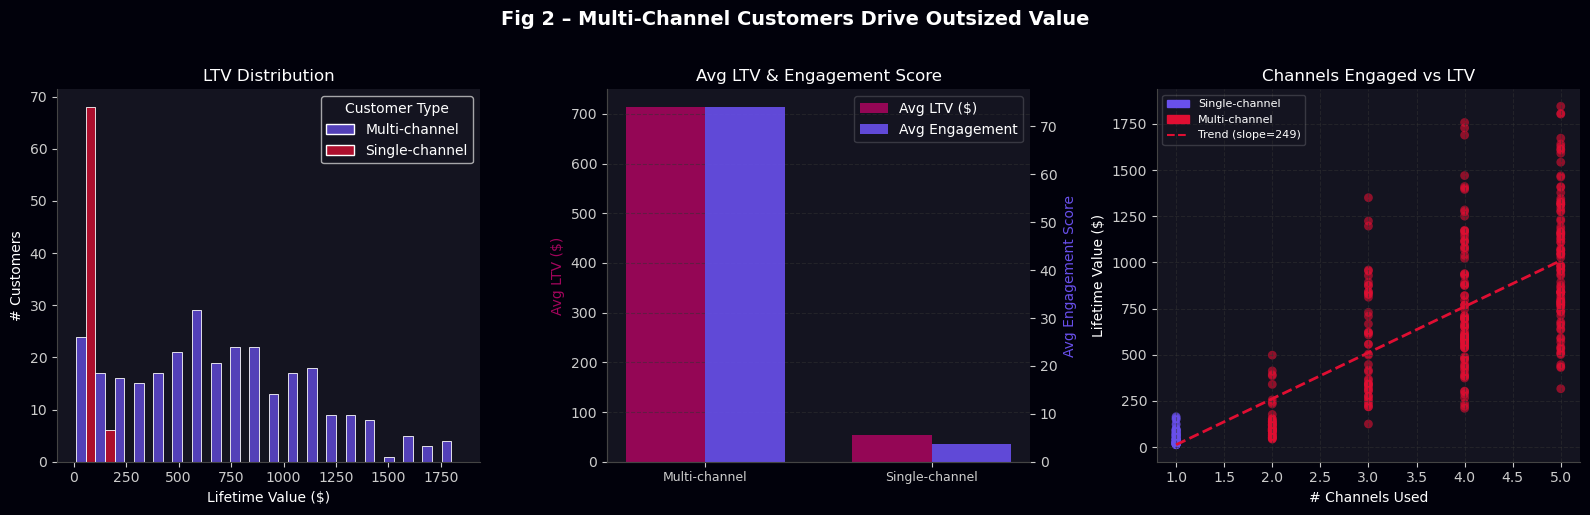

<Figure size 640x480 with 0 Axes>

In [192]:
import seaborn as sns
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Fig 2 – Multi-Channel Customers Drive Outsized Value', fontsize=14, fontweight='bold', y=1.02)

# 2a – LTV distribution
ax = axes[0]

sns.histplot(
    data=analysis,
    x='Lifetime Value',
    hue='Customer Type',
    bins=20,
    multiple='dodge',
    palette=[PALETTE[0], PALETTE[2]],
    ax=ax,
    edgecolor='white'
)

ax.set_xlabel('Lifetime Value ($)')
ax.set_ylabel('# Customers')
ax.set_title('LTV Distribution')

# 2b – Avg LTV & Engagement side-by-side (dual axis)
ax  = axes[1]
ax2 = ax.twinx()
metrics = analysis.groupby('Customer Type')[['Lifetime Value','Engagement Score']].mean()
x, w    = np.arange(2), 0.35
b1 = ax.bar( x - w/2, metrics['Lifetime Value'],   w, color=PALETTE[1], label='Avg LTV ($)',   alpha=0.9)
b2 = ax2.bar(x + w/2, metrics['Engagement Score'], w, color=PALETTE[0], label='Avg Engagement', alpha=0.9)
ax.set_xticks(x); ax.set_xticklabels(metrics.index, fontsize=9)
ax.set_ylabel('Avg LTV ($)', color=PALETTE[1])
ax2.set_ylabel('Avg Engagement Score', color=PALETTE[0])
ax.set_title('Avg LTV & Engagement Score')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, loc='upper right', framealpha=0.2)
ax.grid(axis='y')

# 2c – Channels engaged vs LTV scatter + trend line
ax = axes[2]
colors_ct = analysis['Customer Type'].map({'Single-channel': PALETTE[0], 'Multi-channel': PALETTE[2]})
ax.scatter(analysis['Num Channels'], analysis['Lifetime Value'],
           c=colors_ct, alpha=0.6, s=40, edgecolors='none')
m, b_val = np.polyfit(analysis['Num Channels'], analysis['Lifetime Value'], 1)
xr = np.linspace(1, 5, 100)
ax.plot(xr, m*xr+b_val, '--', color=GES_GOLD, linewidth=2)
ax.set_xlabel('# Channels Used'); ax.set_ylabel('Lifetime Value ($)')
ax.set_title('Channels Engaged vs LTV')
patch1 = mpatches.Patch(color=PALETTE[0], label='Single-channel')
patch2 = mpatches.Patch(color=PALETTE[2], label='Multi-channel')
trend  = plt.Line2D([0],[0], color=GES_GOLD, linestyle='--', label=f'Trend (slope={m:.0f})')
ax.legend(handles=[patch1, patch2, trend], framealpha=0.2, fontsize=8)
ax.grid()

plt.tight_layout()
plt.show()

plt.savefig("Visuals/multi_channel_domination.png", dpi=300, bbox_inches="tight")

For LTV distribution graph, single-channel customers are concentrated in the lower LTV ranges, specifically the 50-100 and 150-200 range, with very little presence outside these ranges.

## 6. Revenue by Business Line

Breaking down total revenue, average transaction value, and transaction count by channel.

In [120]:
rev_bl = df.groupby('Business Line')['Revenue'].agg(['sum','mean','count']).round(2)
rev_bl.columns = ['Total Revenue', 'Avg per Transaction', 'Transaction Count']
rev_bl.sort_values('Total Revenue', ascending=False)

,Total Revenue,Avg per Transaction,Transaction Count
Business Line,,,
Studio Tours,99152.46,195.95,506
Streaming,39688.08,83.55,475
Online Store,32598.48,66.80,488
Consumer Products,27992.49,55.65,503
Theatrical,10704.40,20.27,528


### Fig 3 – Revenue by Business Line

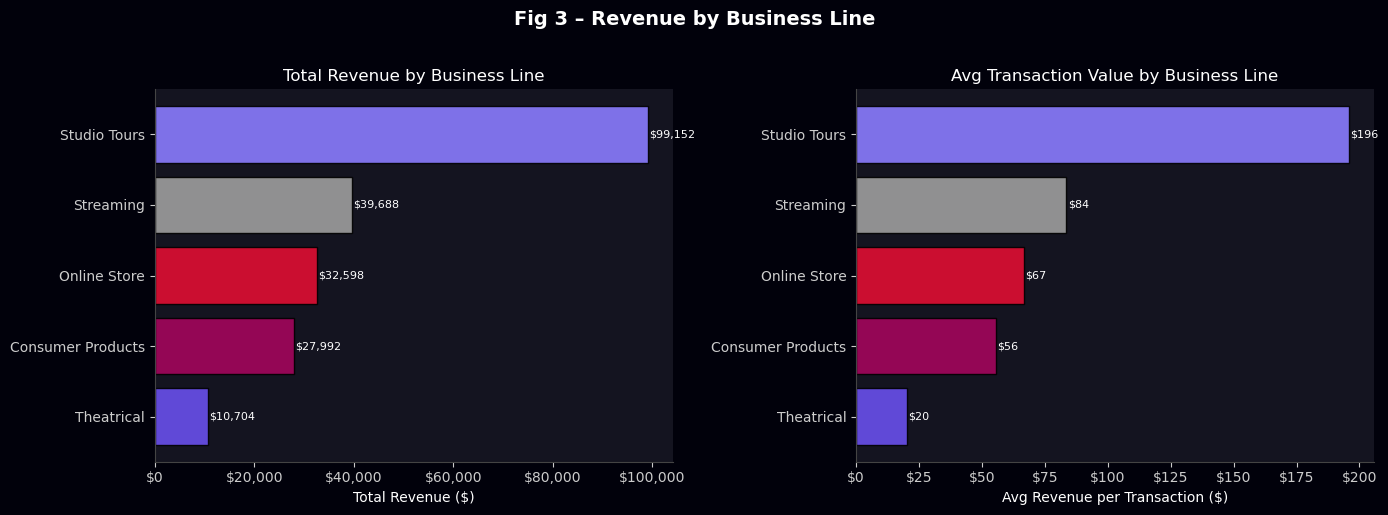

<Figure size 640x480 with 0 Axes>

In [194]:
rev_bl_sorted = rev_bl.sort_values('Total Revenue', ascending=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Fig 3 – Revenue by Business Line', fontsize=14, fontweight='bold', y=1.02)

ax = axes[0]
bars = ax.barh(rev_bl_sorted.index, rev_bl_sorted['Total Revenue'],
               color=PALETTE[:len(rev_bl_sorted)], alpha=0.9, edgecolor='black')
ax.set_xlabel('Total Revenue ($)'); ax.set_title('Total Revenue by Business Line')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
for bar in bars:
    w_val = bar.get_width()
    ax.text(w_val+200, bar.get_y()+bar.get_height()/2, f'${w_val:,.0f}', va='center', fontsize=8)

ax = axes[1]
bars = ax.barh(rev_bl_sorted.index, rev_bl_sorted['Avg per Transaction'],
               color=PALETTE[:len(rev_bl_sorted)], alpha=0.9, edgecolor='black')
ax.set_xlabel('Avg Revenue per Transaction ($)'); ax.set_title('Avg Transaction Value by Business Line')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
for bar in bars:
    w_val = bar.get_width()
    ax.text(w_val+0.5, bar.get_y()+bar.get_height()/2, f'${w_val:,.0f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

plt.savefig("Visuals/revenue_by_business.png", dpi=300, bbox_inches="tight")

## 7. Data Source Impact

Comparing 1st-party vs. 3rd-party channels on revenue and transaction volume.

In [124]:
src_summary = df.groupby('Source Type').agg(
    Total_Revenue   =('Revenue', 'sum'),
    Avg_Revenue     =('Revenue', 'mean'),
    Transactions    =('Transaction ID', 'count')
).round(2)
print(src_summary)

             Total_Revenue  Avg_Revenue  Transactions
Source Type                                          
1st Party        171439.02       116.70          1469
3rd Party         38696.89        37.53          1031


**Note on interpretation:** First-party channels show higher revenue per transaction in this dataset, but this likely reflects **sample bias** rather than a true picture.

The case states that 3rd-party channels (theatrical, retail) represent the *majority* of all customer interactions. Possible reasons for the discrepancy:
1. **Sample bias** – The dataset may overrepresent 1st-party transactions
2. **Different value structures** – Streaming subscriptions and studio tours carry higher per-transaction value than individual merchandise purchases
3. **Interaction ≠ Transaction** – The case counts views and impressions as "interactions"; this dataset only captures revenue-generating events

### Fig 4 – Revenue & Transaction Count by Source Type

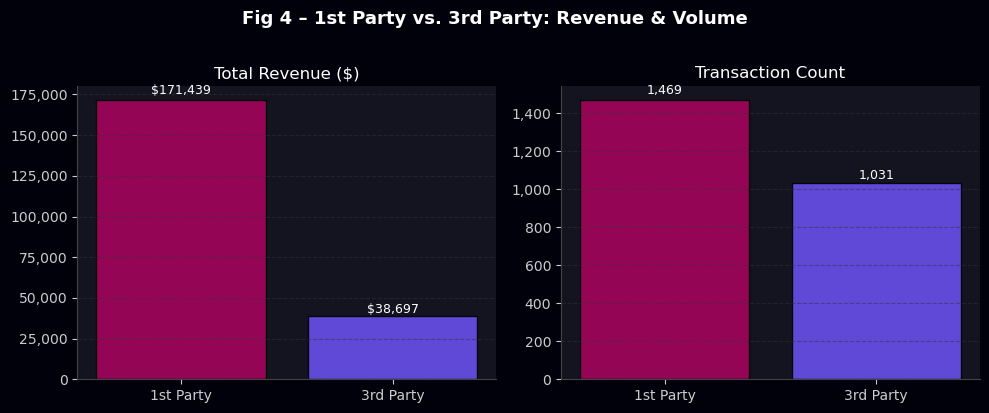

<Figure size 640x480 with 0 Axes>

In [196]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Fig 4 – 1st Party vs. 3rd Party: Revenue & Volume', fontsize=13, fontweight='bold', y=1.02)

for ax, col, title, fmt in [
    (axes[0], 'Total_Revenue',  'Total Revenue ($)',        '${x:,.0f}'),
    (axes[1], 'Transactions',   'Transaction Count',        '{x:,.0f}'),
]:
    bars = ax.bar(src_summary.index, src_summary[col],
                  color=[PALETTE[1], PALETTE[0]], alpha=0.9, edgecolor='black')
    ax.set_title(title); ax.grid(axis='y')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: fmt.format(x=x)))
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h*1.01,
                fmt.format(x=h), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

plt.savefig("Visuals/first_vs_third_revenue_and_volume.png", dpi=300, bbox_inches="tight")

## 8. RFM Customer Segmentation

**RFM** (Recency, Frequency, Monetary) is an industry-standard framework for segmenting customers by behavioral value. Each customer is scored 1–3 on:
- **Recency** – How recently did they transact? (3 = most recent)
- **Frequency** – How many transactions? (3 = most frequent)
- **Monetary** – How much total revenue? (3 = highest spend)

Combined score → 4 segments:
| Score | Segment |
|---|---|
| 8–9 | **Champions** – high-value, recent, frequent |
| 6–7 | **Loyal** – reliable, solid spend |
| 4–5 | **At Risk** – dropping off |
| 3   | **Low Value** – minimal engagement |

In [129]:
ref_date = pd.Timestamp('2025-01-01')

rfm = df.groupby('Customer ID').agg(
    Recency  =('Transaction Date', lambda x: (ref_date - x.max()).days),
    Frequency=('Transaction ID',   'count'),
    Monetary =('Revenue',          'sum')
).reset_index()

# Score 1–3 (3 = best for each dimension)
rfm['R_Score']   = pd.qcut(rfm['Recency'],                     3, labels=[3,2,1]).astype(int)
rfm['F_Score']   = pd.qcut(rfm['Frequency'].rank(method='first'), 3, labels=[1,2,3]).astype(int)
rfm['M_Score']   = pd.qcut(rfm['Monetary'].rank(method='first'),  3, labels=[1,2,3]).astype(int)
rfm['RFM_Total'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

def rfm_segment(score):
    if score >= 8:   return 'Champions'
    elif score >= 6: return 'Loyal'
    elif score >= 4: return 'At Risk'
    else:            return 'Low Value'

rfm['Segment'] = rfm['RFM_Total'].apply(rfm_segment)
rfm.head(10)

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Total,Segment
0,CUST00001,43,7,708.41,2,2,2,6,Loyal
1,CUST00002,47,8,1283.69,2,2,3,7,Loyal
2,CUST00003,178,3,124.72,1,1,1,3,Low Value
3,CUST00004,16,9,840.39,3,2,3,8,Champions
4,CUST00005,90,4,412.37,1,1,2,4,At Risk
5,CUST00006,34,6,609.65,2,2,2,6,Loyal
6,CUST00007,44,8,939.17,2,2,3,7,Loyal
7,CUST00008,21,9,953.04,3,2,3,8,Champions
8,CUST00009,58,6,651.67,2,2,2,6,Loyal
9,CUST00010,177,4,335.55,1,1,2,4,At Risk


In [130]:
# Average RFM metrics by segment
print(rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean().round(1))

           Recency  Frequency  Monetary
Segment                                
At Risk       62.6        3.7     215.2
Champions     18.1       11.7    1073.8
Low Value    189.9        1.6      68.1
Loyal         42.6        7.9     695.5


### Fig 5 – RFM Segment Analysis

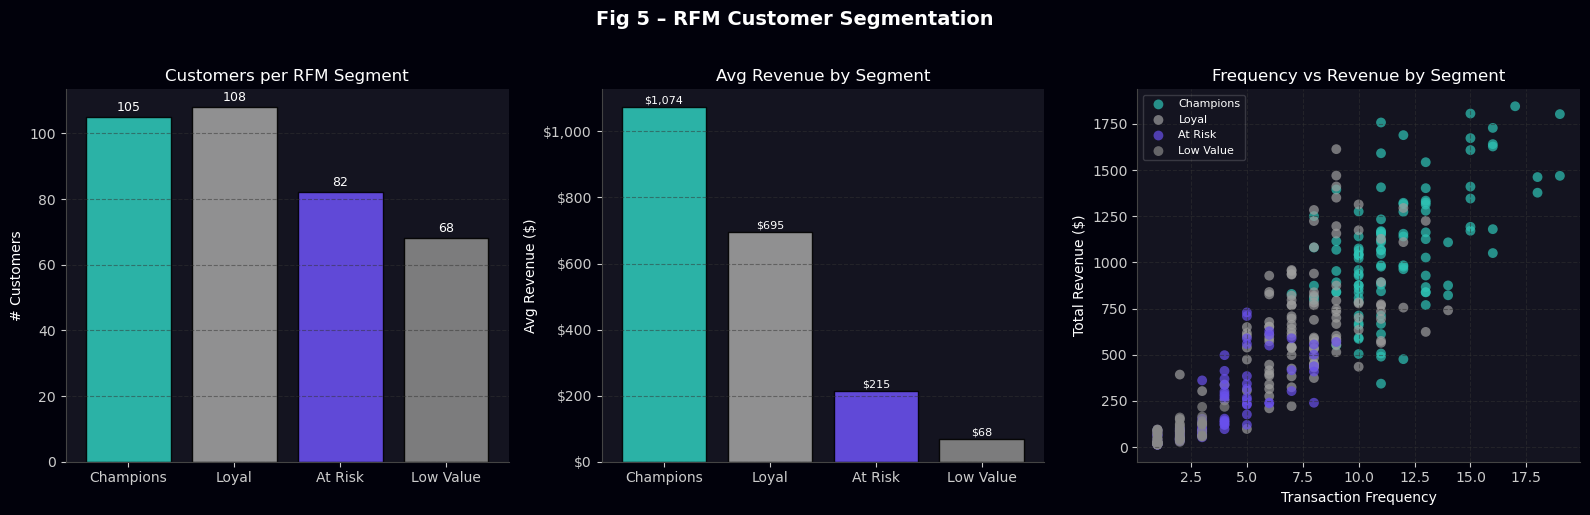

<Figure size 640x480 with 0 Axes>

In [198]:
seg_colors = {'Champions': '#2EC4B6', 'Loyal': PALETTE[3], 'At Risk': PALETTE[0], 'Low Value': '#888'}
seg_order  = ['Champions', 'Loyal', 'At Risk', 'Low Value']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Fig 5 – RFM Customer Segmentation', fontsize=14, fontweight='bold', y=1.02)

# 5a – Count per segment
ax = axes[0]
seg_counts = rfm['Segment'].value_counts().reindex(seg_order)
bars = ax.bar(seg_counts.index, seg_counts.values,
              color=[seg_colors[s] for s in seg_counts.index], alpha=0.9, edgecolor='black')
ax.set_ylabel('# Customers'); ax.set_title('Customers per RFM Segment'); ax.grid(axis='y')
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+1, str(int(h)), ha='center', va='bottom', fontsize=9)

# 5b – Avg revenue per segment
ax = axes[1]
seg_mon = rfm.groupby('Segment')['Monetary'].mean().reindex(seg_order)
bars = ax.bar(seg_mon.index, seg_mon.values,
              color=[seg_colors[s] for s in seg_mon.index], alpha=0.9, edgecolor='black')
ax.set_ylabel('Avg Revenue ($)'); ax.set_title('Avg Revenue by Segment')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax.grid(axis='y')
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+5, f'${h:,.0f}', ha='center', va='bottom', fontsize=8)

# 5c – Scatter: Frequency vs Revenue
ax = axes[2]
for seg, color in seg_colors.items():
    sub = rfm[rfm['Segment']==seg]
    ax.scatter(sub['Frequency'], sub['Monetary'], c=color, label=seg, alpha=0.7, s=50, edgecolors='none')
ax.set_xlabel('Transaction Frequency'); ax.set_ylabel('Total Revenue ($)')
ax.set_title('Frequency vs Revenue by Segment')
ax.legend(framealpha=0.2, fontsize=8); ax.grid()

plt.tight_layout()
plt.show()

plt.savefig("Visuals/rfm_customer_segmentation.png", dpi=300, bbox_inches="tight")

## 9. Revenue Concentration & Trends

### Fig 6 – Revenue Concentration (Pareto) & Monthly Trend

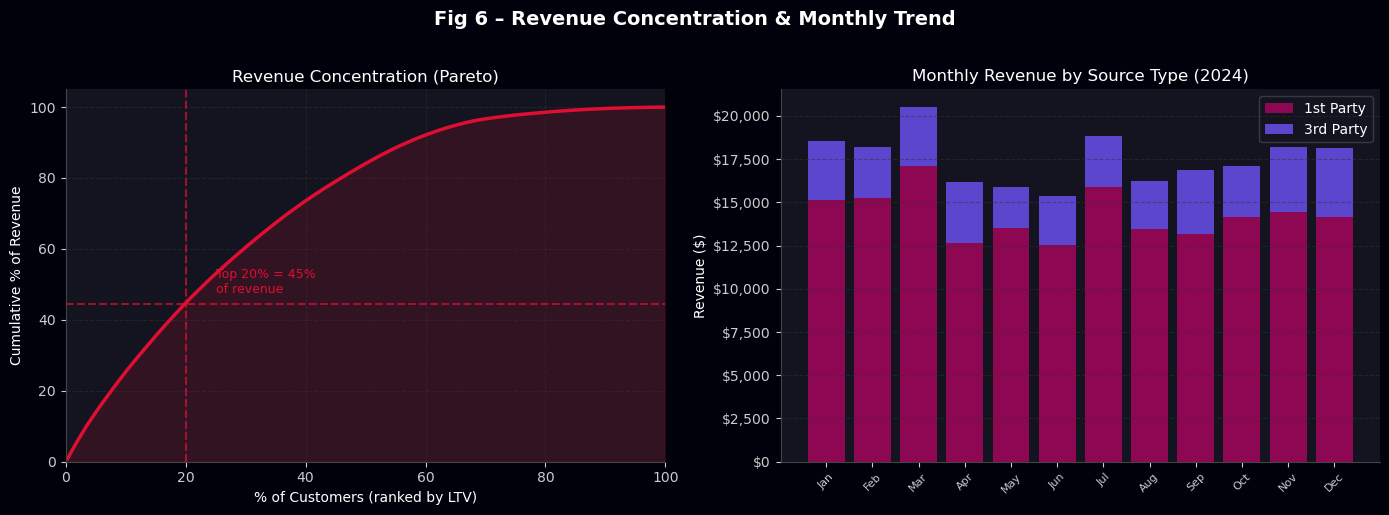

<Figure size 640x480 with 0 Axes>

In [202]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Fig 6 – Revenue Concentration & Monthly Trend', fontsize=14, fontweight='bold', y=1.02)

# 6a – Pareto curve
cp_sorted = customer_profiles.sort_values('Lifetime Value', ascending=False).reset_index(drop=True)
cp_sorted['cum_rev_pct'] = cp_sorted['Lifetime Value'].cumsum() / cp_sorted['Lifetime Value'].sum() * 100
cp_sorted['cust_pct']    = (cp_sorted.index + 1) / len(cp_sorted) * 100

ax = axes[0]
ax.plot(cp_sorted['cust_pct'], cp_sorted['cum_rev_pct'], color=PALETTE[2], linewidth=2.5)
pct_at_20 = cp_sorted[cp_sorted['cust_pct']<=20]['cum_rev_pct'].max()
ax.axvline(20, color=GES_GOLD, linestyle='--', alpha=0.7)
ax.axhline(pct_at_20, color=GES_GOLD, linestyle='--', alpha=0.7)
ax.text(25, pct_at_20+3, f'Top 20% = {pct_at_20:.0f}%\nof revenue', color=GES_GOLD, fontsize=9)
ax.fill_between(cp_sorted['cust_pct'], cp_sorted['cum_rev_pct'], alpha=0.15, color=PALETTE[2])
ax.set_xlabel('% of Customers (ranked by LTV)'); ax.set_ylabel('Cumulative % of Revenue')
ax.set_title('Revenue Concentration (Pareto)'); ax.set_xlim(0,100); ax.set_ylim(0,105); ax.grid()

# 6b – Monthly stacked bar by source type
df['Month'] = df['Transaction Date'].dt.to_period('M')
monthly = df.groupby(['Month','Source Type'])['Revenue'].sum().unstack().fillna(0)
x = np.arange(len(monthly))
ax = axes[1]
ax.bar(x, monthly.get('1st Party', 0), label='1st Party', color=PALETTE[1], alpha=0.85)
ax.bar(x, monthly.get('3rd Party', 0), bottom=monthly.get('1st Party', 0),
       label='3rd Party', color=PALETTE[0], alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels([m.strftime('%b') for m in monthly.index.to_timestamp()], rotation=45, fontsize=8)
ax.set_ylabel('Revenue ($)'); ax.set_title('Monthly Revenue by Source Type (2024)')
ax.legend(framealpha=0.2)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax.grid(axis='y')

plt.tight_layout()
plt.show()

plt.savefig("Visuals/revenue_concentration_and_monthly_trend.png", dpi=300, bbox_inches="tight")

### Fig 7 – Regional & Demographic Breakdown

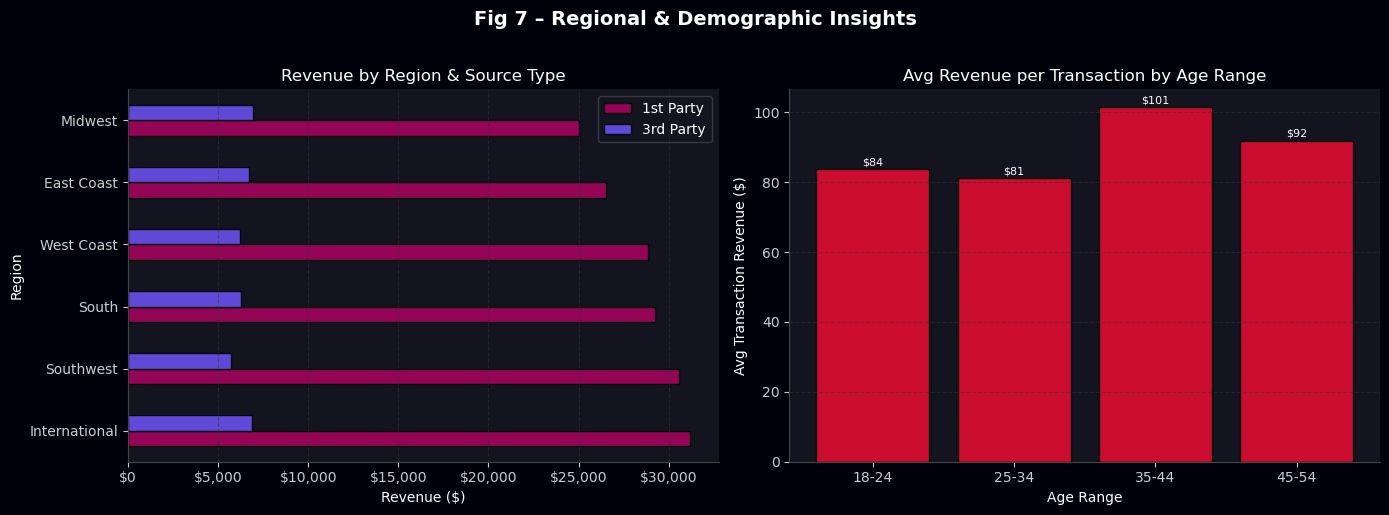

<Figure size 640x480 with 0 Axes>

In [204]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Fig 7 – Regional & Demographic Insights', fontsize=14, fontweight='bold', y=1.02)

# 7a – Revenue by region and source type
reg_src = df.groupby(['Region','Source Type'])['Revenue'].sum().unstack().fillna(0)
reg_src = reg_src.loc[reg_src.sum(axis=1).sort_values(ascending=False).index]
ax = axes[0]
reg_src.plot(kind='barh', ax=ax, color=[PALETTE[1], PALETTE[0]], alpha=0.9, edgecolor='black')
ax.set_xlabel('Revenue ($)'); ax.set_title('Revenue by Region & Source Type')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax.legend(framealpha=0.2); ax.grid(axis='x')

# 7b – Avg transaction revenue by age range (where known)
known      = df[df['Age Range'].notna()].copy()
age_order  = ['18-24','25-34','35-44','45-54','55-64','65+']
age_pres   = [a for a in age_order if a in known['Age Range'].unique()]
age_avg    = [known[known['Age Range']==a]['Revenue'].mean() for a in age_pres]
ax = axes[1]
bars = ax.bar(age_pres, age_avg, color=PALETTE[2], alpha=0.9, edgecolor='black')
ax.set_xlabel('Age Range'); ax.set_ylabel('Avg Transaction Revenue ($)')
ax.set_title('Avg Revenue per Transaction by Age Range'); ax.grid(axis='y')
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+0.5, f'${h:.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

plt.savefig("Visuals/regional_demographic_insights.png", dpi=300, bbox_inches="tight")

### Fig 8 – Channel Co-Engagement Matrix

Which channel pairs are most commonly used together? This identifies the strongest cross-sell opportunities.

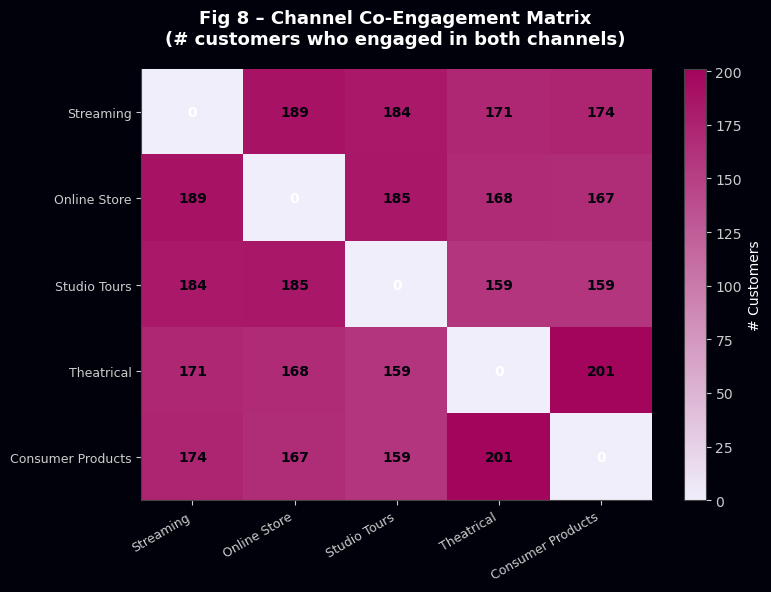

<Figure size 640x480 with 0 Axes>

In [206]:
channels     = ['Streaming','Online Store','Studio Tours','Theatrical','Consumer Products']
cust_channels = df.groupby('Customer ID')['Business Line'].apply(set)
matrix        = pd.DataFrame(0, index=channels, columns=channels)

for _, chans in cust_channels.items():
    cl = [c for c in chans if c in channels]
    for i in range(len(cl)):
        for j in range(len(cl)):
            if i != j:
                matrix.loc[cl[i], cl[j]] += 1

cmap = LinearSegmentedColormap.from_list('ges', ['#F0EEFB', '#a3055c'])
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('Fig 8 – Channel Co-Engagement Matrix\n(# customers who engaged in both channels)',
             fontsize=13, fontweight='bold')

im = ax.imshow(matrix.values, cmap=cmap, aspect='auto')
ax.set_xticks(range(len(channels))); ax.set_xticklabels(channels, rotation=30, ha='right', fontsize=9)
ax.set_yticks(range(len(channels))); ax.set_yticklabels(channels, fontsize=9)

for i in range(len(channels)):
    for j in range(len(channels)):
        val = matrix.values[i,j]
        ax.text(j, i, str(val), ha='center', va='center', fontsize=10, fontweight='bold',
                color='white' if val < matrix.values.max()*0.5 else GES_DARK)

plt.colorbar(im, ax=ax, label='# Customers')
plt.tight_layout()
plt.show()

plt.savefig("Visuals/co_engagement_heatmap.png", dpi=300, bbox_inches="tight")

## 10. Key Statistics Summary

Headline numbers to reference in the written proposal and presentation.

In [141]:
total_customers = customer_profiles['Customer ID'].nunique()
multi_ch        = (customer_profiles['Business Lines Engaged'] > 1).sum()
single_ch       = (customer_profiles['Business Lines Engaged'] == 1).sum()
ltv_multi       = customer_profiles[customer_profiles['Business Lines Engaged']>1]['Lifetime Value'].mean()
ltv_single      = customer_profiles[customer_profiles['Business Lines Engaged']==1]['Lifetime Value'].mean()
total_rev       = df['Revenue'].sum()
dark_rev        = df[(df['Source Type']=='3rd Party') & (df['Email'].isna())]['Revenue'].sum()

print('=' * 55)
print('KEY STATS FOR PROPOSAL')
print('=' * 55)
print(f'Total customers            : {total_customers}')
print(f'Multi-channel customers    : {multi_ch} ({multi_ch/total_customers:.0%})')
print(f'Single-channel customers   : {single_ch} ({single_ch/total_customers:.0%})')
print(f'Avg LTV – multi-channel    : ${ltv_multi:,.0f}')
print(f'Avg LTV – single-channel   : ${ltv_single:,.0f}')
print(f'Multi-channel LTV premium  : {ltv_multi/ltv_single:.1f}x')
print(f'Total dataset revenue      : ${total_rev:,.0f}')
print(f'"Dark" revenue (no email)  : ${dark_rev:,.0f} ({dark_rev/total_rev:.1%})')
print()
print('RFM Segment Breakdown:')
for seg in ['Champions','Loyal','At Risk','Low Value']:
    sub = rfm[rfm['Segment']==seg]
    print(f'  {seg:<14}: {len(sub):>3} customers | avg revenue ${sub["Monetary"].mean():,.0f}')

KEY STATS FOR PROPOSAL
Total customers            : 363
Multi-channel customers    : 289 (80%)
Single-channel customers   : 74 (20%)
Avg LTV – multi-channel    : $714
Avg LTV – single-channel   : $53
Multi-channel LTV premium  : 13.5x
Total dataset revenue      : $210,136
"Dark" revenue (no email)  : $8,029 (3.8%)

RFM Segment Breakdown:
  Champions     : 105 customers | avg revenue $1,074
  Loyal         : 108 customers | avg revenue $695
  At Risk       :  82 customers | avg revenue $215
  Low Value     :  68 customers | avg revenue $68
